# Bolting a PTZ gimbal to a helicopter

`dgs.ptz_camera` derives a 2-DOF gimbal's pointing, statics, and dynamics
assuming the base is fixed. Bolt that same gimbal to a helicopter and the
base itself vibrates -- rotor imbalance and blade-pass forces shake the
airframe at well-known, narrow frequencies, and that shaking couples
straight into where the camera actually points, whether or not the gimbal
motors move at all.

The key relation (kept to the tilt axis for clarity):

$$\text{inertial\_tilt}(t) = \text{base\_disturbance}(t) + \text{gimbal\_relative\_tilt}(t)$$

What matters for keeping a target in frame is the INERTIAL angle, not the
angle relative to the camera's own mounting bracket.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt

from dgs.ptz_camera import forward_dynamics
from dgs.pid import PID
from dgs.ptz_helicopter_stabilization import (
    base_disturbance_tilt, simulate_stabilization, verify_stabilization_reduces_error,
    default_gimbal_params, MAIN_ROTOR_HZ, BLADE_PASS_HZ, N_BLADES,
)
print(f"Disturbance model: main rotor {MAIN_ROTOR_HZ:.1f} Hz, "
      f"blade-pass {BLADE_PASS_HZ:.1f} Hz ({N_BLADES}-bladed rotor)")

Disturbance model: main rotor 5.5 Hz, blade-pass 11.0 Hz (2-bladed rotor)


## Part 1 -- the disturbance: what a helicopter actually does to its own airframe

A light helicopter's main rotor turns at roughly 300-400 RPM (~5-7 Hz,
"1/rev"); a 2-bladed teetering rotor's dominant vibration is at BLADE-PASS
frequency, 2x that. Modeled here as a single sinusoid -- real airframe
vibration is a narrowband spectrum peaked at this frequency, but a pure
tone is the right first test of whether a controller can reject it at
all.

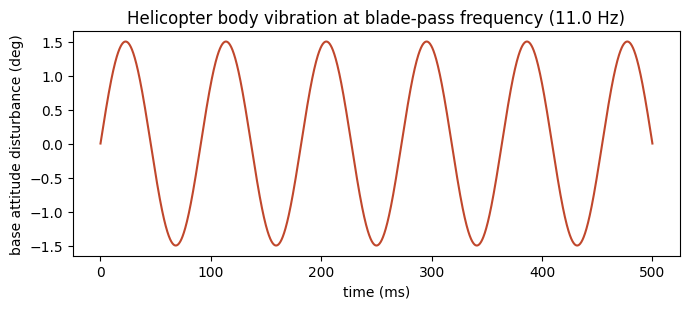

In [2]:
t = np.linspace(0, 0.5, 2000)
disturbance = base_disturbance_tilt(t, amplitude_deg=1.5)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(t * 1000, np.degrees(disturbance), color='#c0472c')
ax.set_xlabel('time (ms)'); ax.set_ylabel('base attitude disturbance (deg)')
ax.set_title(f'Helicopter body vibration at blade-pass frequency ({BLADE_PASS_HZ:.1f} Hz)')
fig.tight_layout()
plt.show()

## Part 2 -- two controllers, same gains, same plant, different measurement

Both cases below use the exact same `dgs.pid.PID` structure and gains,
and the exact same `dgs.ptz_camera.forward_dynamics` tilt-axis physics.
The only thing that changes is what the controller is told to measure:

- **`reference="relative"`**: holds the gimbal's tilt at 0 relative to its
  own mounting bracket -- a basic position-hold servo with no idea the
  base is rotating (no gyro feedback). This is the realistic
  *unstabilized* baseline -- not "zero torque" (which just free-falls
  under gravity, exactly like `dgs.ptz_camera`'s own pendulum demo), but
  "holds its own angle and nothing more."
- **`reference="inertial"`**: measures the INERTIAL tilt -- the number a
  gyroscope mounted on the camera itself would report -- and actively
  counter-rotates to cancel the disturbance. This is what a real 3-axis
  stabilized gimbal does.

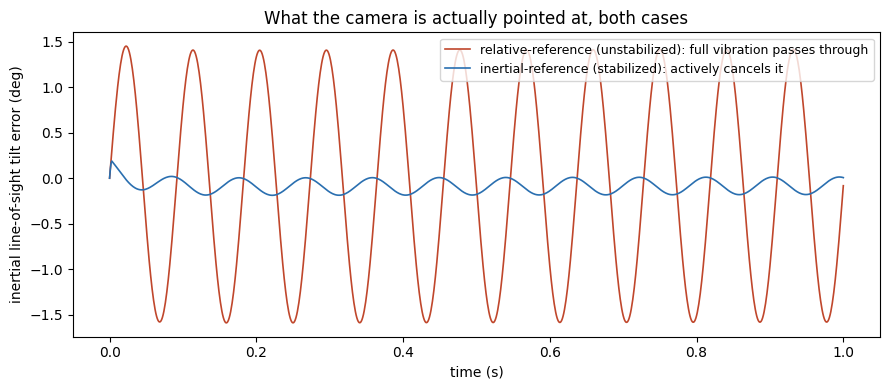

In [3]:
relative = simulate_stabilization(t_end=1.0, reference='relative')
inertial = simulate_stabilization(t_end=1.0, reference='inertial')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(relative['t'], np.degrees(relative['inertial_tilt']), color='#c0472c', lw=1.2,
        label='relative-reference (unstabilized): full vibration passes through')
ax.plot(inertial['t'], np.degrees(inertial['inertial_tilt']), color='#2a6fb0', lw=1.2,
        label='inertial-reference (stabilized): actively cancels it')
ax.set_xlabel('time (s)'); ax.set_ylabel('inertial line-of-sight tilt error (deg)')
ax.set_title('What the camera is actually pointed at, both cases')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Part 3 -- does inertial reference actually help, quantitatively?

`verify_stabilization_reduces_error` runs both cases from identical
conditions and compares RMS inertial pointing error -- the real number
that determines whether footage is usable, not just a plot that looks
better by eye.

In [4]:
check = verify_stabilization_reduces_error()
print(f"relative-reference RMS error: {np.degrees(check['relative_reference_rms_rad']):.3f} deg")
print(f"inertial-reference RMS error: {np.degrees(check['inertial_reference_rms_rad']):.4f} deg")
print(f"improvement: {check['improvement_ratio']:.1f}x")
print(f"meaningfully improved (>5x): {check['meaningfully_improved']}")

threshold_deg = 0.1  # illustrative usability scale, not a specific lens/sensor spec
stabilized_deg = np.degrees(check['inertial_reference_rms_rad'])
print(f"\nillustrative usability threshold: {threshold_deg} deg -> "
      f"{'PASSES' if stabilized_deg < threshold_deg else 'still exceeds it'}")

relative-reference RMS error: 1.064 deg
inertial-reference RMS error: 0.1063 deg
improvement: 10.0x
meaningfully improved (>5x): True

illustrative usability threshold: 0.1 deg -> still exceeds it


## Part 4 -- what does the controller actually have to do?

The torque command itself: an inertially-referenced controller has to
work much harder (bigger, faster-changing commands) than one that's only
holding a fixed relative angle, because it's actively fighting the
disturbance instead of ignoring it.

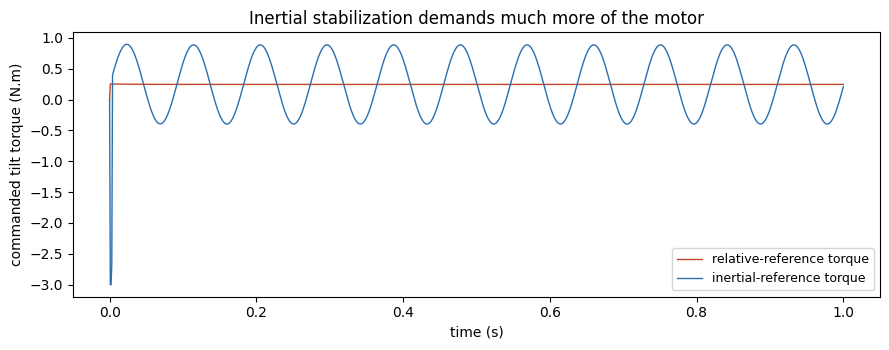

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(relative['t'], relative['torque'], color='#c0472c', lw=1, label='relative-reference torque')
ax.plot(inertial['t'], inertial['torque'], color='#2a6fb0', lw=1, label='inertial-reference torque')
ax.set_xlabel('time (s)'); ax.set_ylabel('commanded tilt torque (N.m)')
ax.set_title('Inertial stabilization demands much more of the motor')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Summary

| | Relative-reference (unstabilized) | Inertial-reference (stabilized) |
|---|---|---|
| Measures | gimbal angle vs. its own bracket | gimbal angle vs. the world (gyro) |
| Disturbance response | passes straight through | actively cancelled |
| Motor effort | low (just holds level) | high (constantly counter-rotating) |

This is the actual reason real gimbals (drone/helicopter camera mounts)
need an IMU on the camera itself, not just a position encoder at the
motor: the encoder can only tell the controller where the camera is
relative to a mount that's itself moving. Same controller, same plant,
same gains -- the only thing that changed was which physical quantity got
measured, and that alone was the difference between usable and unusable
footage.